# Hyperparameter optimization for iterative ptychography

Iterative ptychography has a number of hyperparameters that are hard to know _a-priori_ — probe defocus, convergence semiangle, learning rates, and so on — and getting them wrong degrades the reconstruction.
This notebook shows how to estimate them from the data using `OptimizePtychography`, which wraps [Optuna](https://optuna.org/) Bayesian optimization around the full reconstruction pipeline:

1. run a quick baseline reconstruction with the known (true) parameters,
2. optimize the probe defocus with Optuna,
3. chain a second study that keeps the best defocus and adds the semiangle,
4. run a simple grid search and inspect the reconstructed objects at each grid point.

Each optimization trial builds a fresh `Ptychography` (or `PtychoLite`) instance, runs a short reconstruction, and reports the final data-fidelity loss back to Optuna.
The example uses the included `ducky` dataset (true defocus 500 Å, true semiangle 20 mrad) so the full pipeline is runnable end-to-end with modest run times.

Stephanie Ribet and Arthur McCray


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.visualization import show_2d
from quantem.diffractive_imaging.dataset_models import PtychographyDatasetRaster
from quantem.diffractive_imaging.detector_models import DetectorPixelated
from quantem.diffractive_imaging.object_models import ObjectPixelated
from quantem.diffractive_imaging.optimize_hyperparameters import (
    OptimizationParameter,
    OptimizePtychography,
)
from quantem.diffractive_imaging.probe_models import ProbePixelated
from quantem.diffractive_imaging.ptychography import Ptychography
from quantem.diffractive_imaging.ptychography_lite import PtychoLite

GPU_ID = 0
print(f"quantEM version: {em.__version__}")
# Select the default compute device for this session.
if torch.cuda.is_available():
    print(f"There are {torch.cuda.device_count()} GPUs available")
    config.set_device(GPU_ID)
    print(f"Using device {config.get('device')} | {torch.cuda.get_device_name(config.get('device'))}")
else:
    if torch.backends.mps.is_available():
        print("No GPUs available, using MPS")
        config.set_device("mps")
    else:
        print("No GPUs available, using CPU")
        config.set_device("cpu")

/home/amccray/code/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


quantEM version: 0.1.8
There are 4 GPUs available
Using device cuda:0 | NVIDIA RTX PRO 6000 Blackwell Server Edition


## Load the simulated dataset
The `ducky` dataset used here is bundled with the repository, and was simulated with a known probe: 80 kV, 20 mrad semiangle, 500 Å defocus.
Knowing the ground truth lets us check that the optimization actually recovers the right values.
If you want to regenerate the dataset, see `simulation_notebooks/ducky-dataset.ipynb`.

In [3]:
filepath = Path("../../data/ducky_251105_20mrad_500A-df_4A-step_5e+04-dose_clean.zip")
dset: Dataset4dstem = em.io.load(filepath)
print(dset)

PROBE_ENERGY = 80e3  # eV, accelerating voltage
PROBE_SEMIANGLE = 20  # mrad, probe convergence semiangle (true value)
PROBE_DEFOCUS = 500  # A, probe defocus (true value)

quantem Dataset named 'ducky_251105_clean'
  shape: (37, 37, 200, 200)
  dtype: float32
  device: cpu
  origin: [0. 0. 0. 0.]
  sampling: [4.    4.    0.025 0.025]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'


Calculated best fit rotation = 0 degrees.


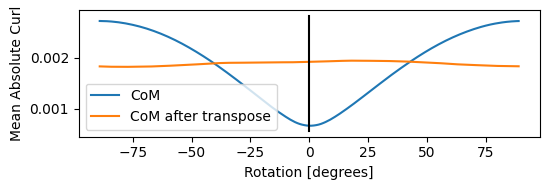

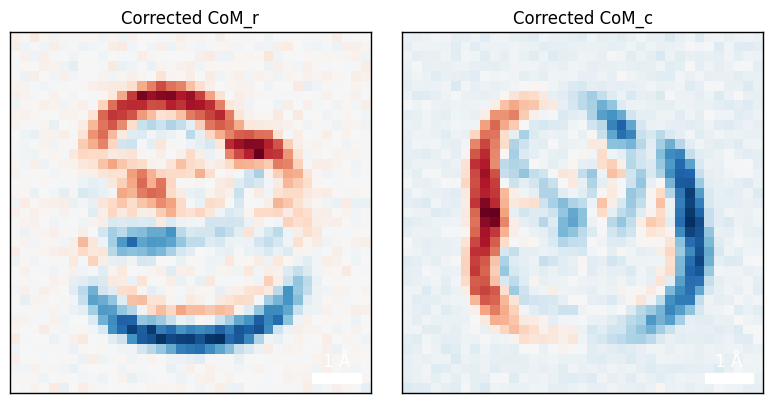

Normalizing intensities: 100%|██████████| 1369/1369 [00:01<00:00, 840.66probe position/s]


In [4]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)

pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=True,
    plot_com=True,
)

## Baseline reconstruction
First we run a quick reconstruction with the true probe parameters so we know what a good result looks like.
We use the component-level `Ptychography.from_models` interface here because the hyperparameter optimizer below is built around the same constructors.

In [5]:
obj_model = ObjectPixelated.from_uniform(
    num_slices=1,
    obj_type="pure_phase",
)

probe_model = ProbePixelated.from_params(
    num_probes=1,
    probe_params={
        "energy": PROBE_ENERGY,
        "defocus": PROBE_DEFOCUS,
        "semiangle_cutoff": PROBE_SEMIANGLE,
    },
)

detector_model = DetectorPixelated()

ptycho = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model,
    probe_model=probe_model,
    detector_model=detector_model,
    device="gpu",
    rng=42,
)

ptycho.preprocess(
    obj_padding_px=(32, 32),
)

Iter 30/30, Loss: 4.986e+00: 100%|██████████| 30/30 [00:01<00:00, 15.38it/s]


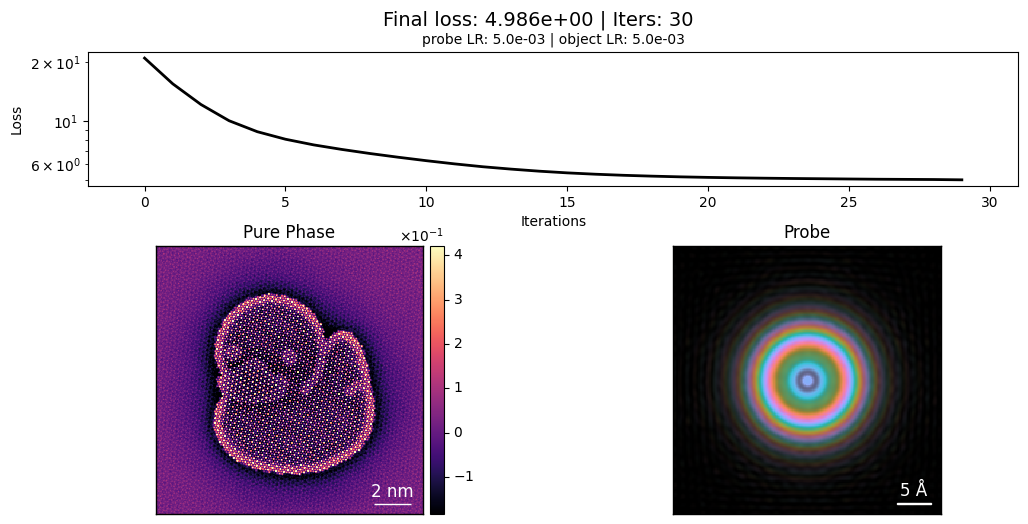

In [6]:
optimizer_params = {
    "object": {"name": "adam", "lr": 5e-3},
    "probe": {"name": "adam", "lr": 5e-3},
}

ptycho.reconstruct(
    num_iters=30,
    reset=True,
    optimizer_params=optimizer_params,
    batch_size=125,
    device="gpu",
).visualize()

(<Figure size 800x400 with 2 Axes>,
 array([<Axes: title={'center': 'pixelated pure_phase | 30 iterations | defocus 500 A'}>,
        <Axes: title={'center': 'zoom'}>], dtype=object))

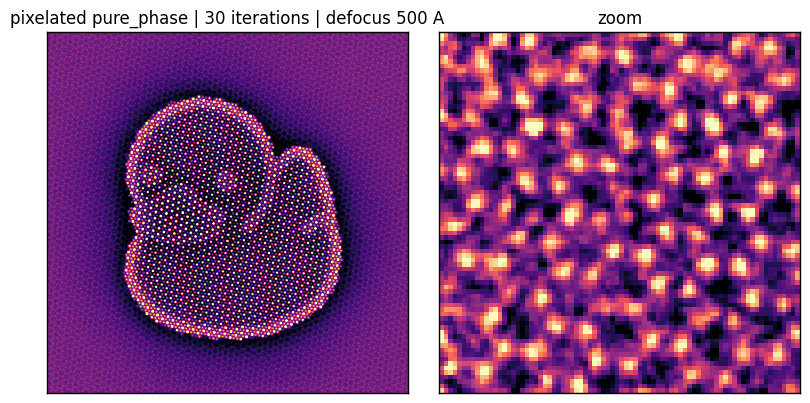

In [7]:
ph = ptycho.obj_cropped[0]
if ptycho.obj_model.obj_type == "complex":
    ph = np.angle(ph)
show_2d(
    [ph, ph[:80, :80]],
    cmap="magma",
    title=[
        f"pixelated {ptycho.obj_model.obj_type} | {ptycho.num_iters} iterations | defocus {PROBE_DEFOCUS} A",
        "zoom",
    ],
)

## Bayesian optimization with Optuna
Now suppose we didn't know the defocus. `OptimizePtychography.from_constructors` takes two things:

- `constructors`: a dict mapping the component names `"object"`, `"probe"`, `"detector"` to their factory functions, plus `"ptychography_class"` for the main class (`Ptychography.from_models` here, or `PtychoLite.from_dataset` — see the last section).
- `base_kwargs`: a nested dict of keyword arguments. The `"object"` / `"probe"` / `"detector"` sections feed the component constructors, `"init"` feeds `ptychography_class`, and `"preprocess"` / `"reconstruct"` feed those methods on the assembled instance.

Anywhere in `base_kwargs` you can replace a fixed value with an `OptimizationParameter(low, high)`, and Optuna will sample it each trial (pass `log=True` for log-uniform sampling, e.g. for learning rates).
Each trial gets its own private copy of the dataset, builds the models, runs `preprocess` and `reconstruct`, and returns the final reconstruction loss (you can pass a custom `loss_getter` callable to score trials differently).

We keep `num_iters` and `n_trials` small so the notebook runs quickly; for real datasets a common rule of thumb is ~50 trials per free parameter.

In [8]:
constructors = {
    "object": ObjectPixelated.from_uniform,
    "probe": ProbePixelated.from_params,
    "detector": DetectorPixelated,
    "ptychography_class": Ptychography.from_models,
}

base_kwargs = {
    "object": {
        "num_slices": 1,
        "obj_type": "pure_phase",
    },
    "probe": {
        "num_probes": 1,
        "probe_params": {
            "energy": PROBE_ENERGY,
            "semiangle_cutoff": PROBE_SEMIANGLE,
            # this will be sampled each trial by Optuna
            "defocus": OptimizationParameter(low=300, high=700),
        },
    },
    "detector": {},
    "init": {
        "dset": pdset,
        "device": "gpu",
        "rng": 42,
    },
    "preprocess": {
        "obj_padding_px": (32, 32),
    },
    "reconstruct": {
        "num_iters": 10,
        "reset": True,
        "optimizer_params": optimizer_params,
        "batch_size": 125,
        "device": "gpu",
    },
}

defocus_opt = OptimizePtychography.from_constructors(
    constructors=constructors,
    base_kwargs=base_kwargs,
    n_trials=10,
    verbose=False,
)
defocus_opt.optimize()

optimizing:   0%|          | 0/10 [00:00<?, ?trial/s]

optimizing: 100%|██████████| 10/10 [00:14<00:00,  1.48s/trial]


Trial parameters are named by their dotted path inside `base_kwargs`, so the defocus is `"probe.probe_params.defocus"`.
The underlying `optuna` study is available as `defocus_opt.study` for anything the wrapper doesn't expose directly.

best defocus: 455 A | true defocus: 500 A
best loss: 6.101e+00


(<Figure size 1000x600 with 1 Axes>,
 array([<Axes: title={'center': 'probe.probe_params.defocus'}, xlabel='defocus', ylabel='Loss'>],
       dtype=object))

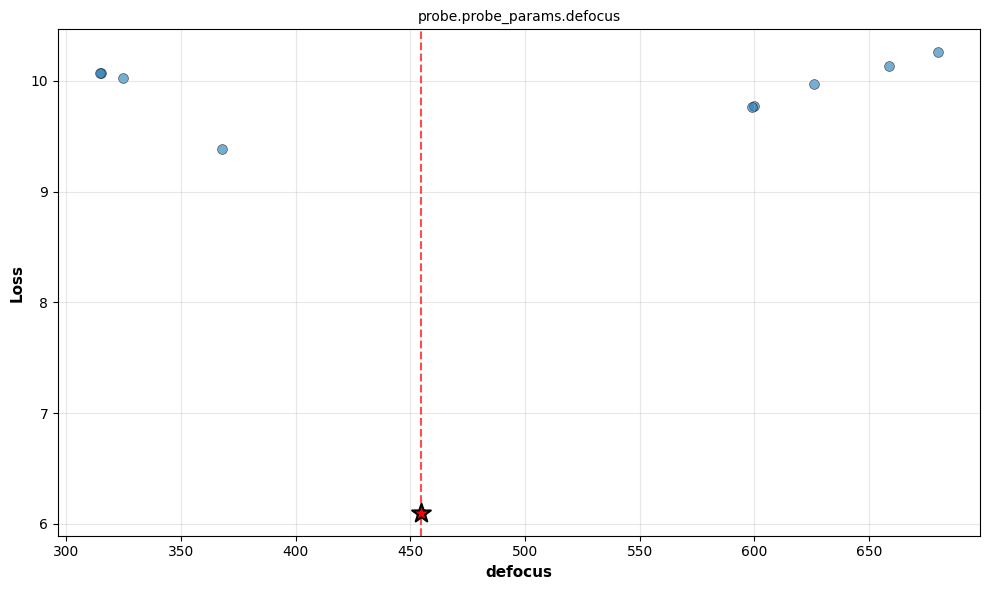

In [9]:
best_defocus = defocus_opt.study.best_params["probe.probe_params.defocus"]
print(f"best defocus: {best_defocus:.0f} A | true defocus: {PROBE_DEFOCUS} A")
print(f"best loss: {defocus_opt.study.best_value:.3e}")

defocus_opt.visualize()

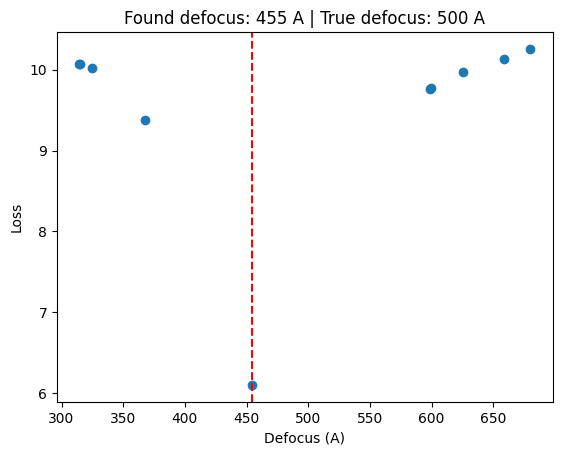

In [10]:
trials = [t for t in defocus_opt.study.trials if t.values is not None]
defocus_values = np.array([t.params["probe.probe_params.defocus"] for t in trials])
losses = np.array([t.values[0] for t in trials])

fig, ax = plt.subplots()
ax.scatter(defocus_values, losses)
ax.axvline(best_defocus, color="red", linestyle="--")
ax.set_title(f"Found defocus: {best_defocus:.0f} A | True defocus: {PROBE_DEFOCUS} A")
ax.set_xlabel("Defocus (A)")
ax.set_ylabel("Loss")
plt.show()

## Chaining studies with `from_optimizer`
Optimizing parameters one or two at a time is usually far more efficient than optimizing everything at once.
`OptimizePtychography.from_optimizer` takes a finished study, fixes every previously-optimized parameter at its best value, and lets you add new `OptimizationParameter`s — here the convergence semiangle, keyed by the same dotted path.

In [11]:
semiangle_opt = OptimizePtychography.from_optimizer(
    previous_study=defocus_opt.study,
    new_params={
        "probe.probe_params.semiangle_cutoff": OptimizationParameter(low=10, high=30),
    },
    n_trials=10,
)
semiangle_opt.optimize()

optimizing: 100%|██████████| 10/10 [00:14<00:00,  1.45s/trial]


best semiangle: 20.3 mrad | true semiangle: 20 mrad
(defocus fixed at 455 A from the previous study)


(<Figure size 1000x600 with 1 Axes>,
 array([<Axes: title={'center': 'probe.probe_params.semiangle_cutoff'}, xlabel='semiangle_cutoff', ylabel='Loss'>],
       dtype=object))

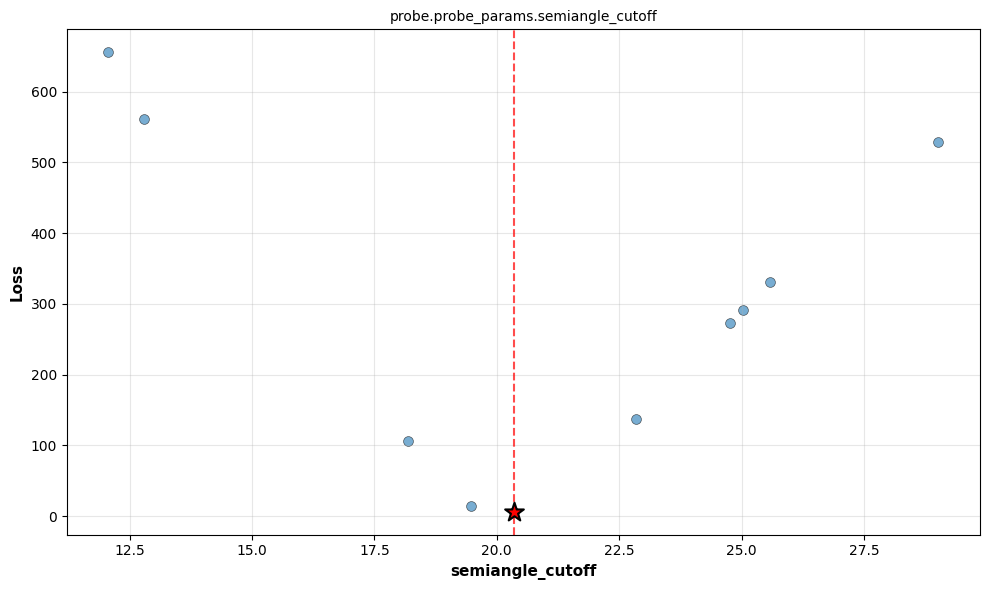

In [12]:
best_semiangle = semiangle_opt.study.best_params["probe.probe_params.semiangle_cutoff"]
print(f"best semiangle: {best_semiangle:.1f} mrad | true semiangle: {PROBE_SEMIANGLE} mrad")
print(f"(defocus fixed at {best_defocus:.0f} A from the previous study)")

semiangle_opt.visualize()

## Grid search
For a small number of parameters it is often useful to scan a regular grid instead — mostly because you can then _look_ at every reconstruction, and the eye is a better judge of reconstruction quality than the loss.
Give each `OptimizationParameter` an `n_points`, and `grid_search()` evaluates every combination and plots the reconstructed object at each grid point (the best-loss reconstruction is outlined in red).


Running reconstructions...


Grid search:   0%|          | 0/5 [00:00<?, ?point/s]

Grid search: 100%|██████████| 5/5 [00:07<00:00,  1.42s/point]


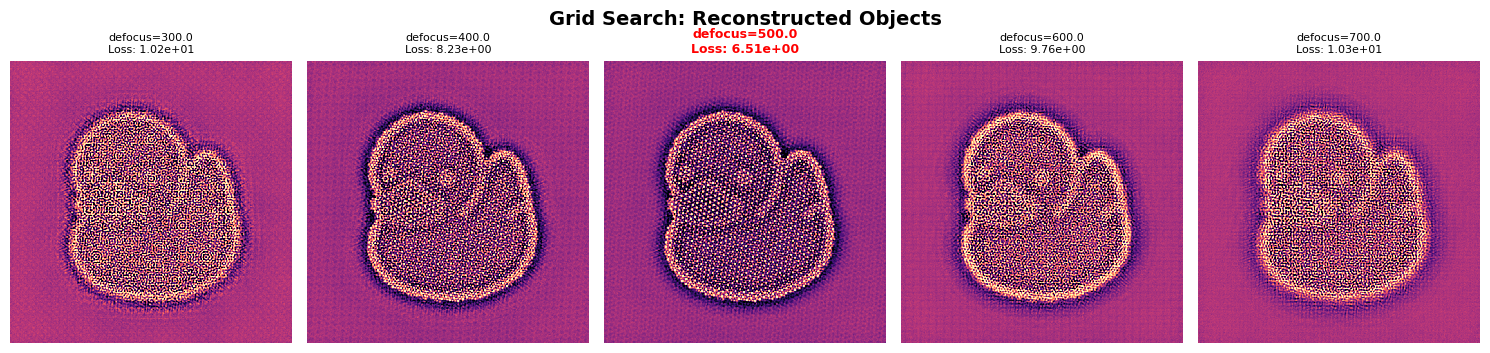

In [13]:
grid_kwargs = {
    "object": {
        "num_slices": 1,
        "obj_type": "pure_phase",
    },
    "probe": {
        "num_probes": 1,
        "probe_params": {
            "energy": PROBE_ENERGY,
            "semiangle_cutoff": PROBE_SEMIANGLE,
            "defocus": OptimizationParameter(low=300, high=700, n_points=5),
        },
    },
    "detector": {},
    "init": {
        "dset": pdset,
        "device": "gpu",
        "rng": 42,
    },
    "preprocess": {
        "obj_padding_px": (32, 32),
    },
    "reconstruct": {
        "num_iters": 10,
        "reset": True,
        "optimizer_params": optimizer_params,
        "batch_size": 125,
        "device": "gpu",
    },
}

grid_opt = OptimizePtychography.from_constructors(
    constructors=constructors,
    base_kwargs=grid_kwargs,
    verbose=False,
)
grid_results = grid_opt.grid_search(plot_objects=True, return_results=True)

In [14]:
best = grid_results["best_result"]
print(f"best grid point: {best['params']} | loss: {best['loss']:.3e}")

best grid point: {'probe.probe_params.defocus': np.float64(500.0)} | loss: 6.511e+00


## Optimizing `PtychoLite`
The same optimizer drives the high-level `PtychoLite` interface.
Since `PtychoLite.from_dataset` builds all the component models itself, the config is simpler: `constructors` only needs `"ptychography_class"`, and `base_kwargs` only needs `"init"` and `"reconstruct"` sections.

In [15]:
lite_constructors = {
    "ptychography_class": PtychoLite.from_dataset,
}

lite_kwargs = {
    "init": {
        "dset": pdset,
        "num_slices": 1,
        "num_probes": 1,
        "obj_type": "pure_phase",
        "energy": PROBE_ENERGY,
        "semiangle_cutoff": PROBE_SEMIANGLE,
        "defocus": OptimizationParameter(low=300, high=700),
        "obj_padding_px": (32, 32),
        "device": "gpu",
        "rng": 42,
    },
    "reconstruct": {
        "num_iters": 10,
        "reset": True,
        "lr_obj": 5e-3,
        "lr_probe": 5e-3,
        "batch_size": 125,
        "device": "gpu",
    },
}

lite_opt = OptimizePtychography.from_constructors(
    constructors=lite_constructors,
    base_kwargs=lite_kwargs,
    n_trials=10,
    verbose=False,
)
lite_opt.optimize()

optimizing:   0%|          | 0/10 [00:00<?, ?trial/s]

optimizing: 100%|██████████| 10/10 [00:14<00:00,  1.47s/trial]


best defocus: 481 A | true defocus: 500 A


(<Figure size 1000x600 with 1 Axes>,
 array([<Axes: title={'center': 'init.defocus'}, xlabel='defocus', ylabel='Loss'>],
       dtype=object))

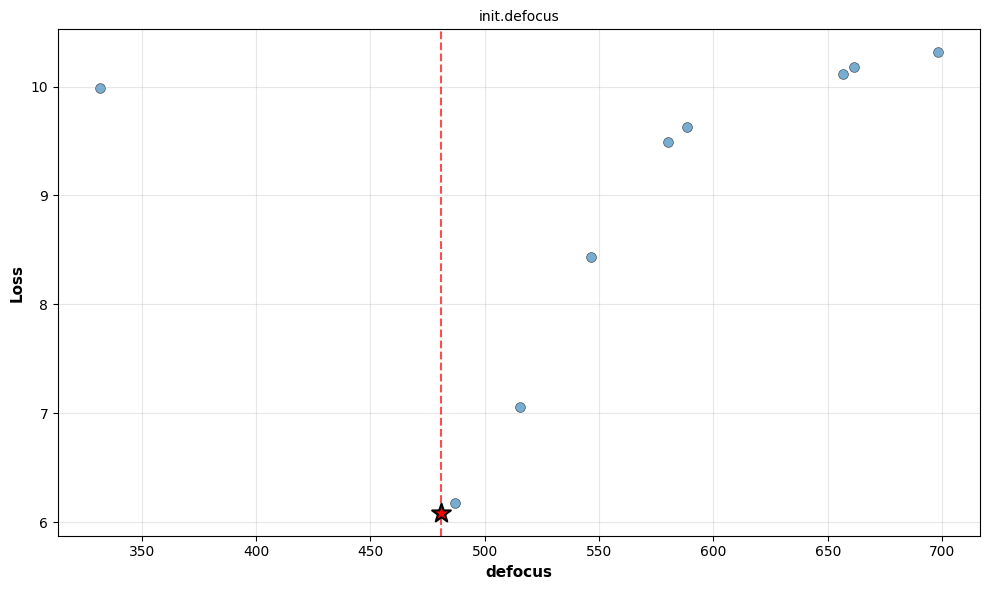

In [16]:
best_defocus_lite = lite_opt.study.best_params["init.defocus"]
print(f"best defocus: {best_defocus_lite:.0f} A | true defocus: {PROBE_DEFOCUS} A")

lite_opt.visualize()

## Reconstruct with the optimized parameters
Finally, run a longer reconstruction using the values the optimization found.

Iter 100/100, Loss: 4.474e+00: 100%|██████████| 100/100 [00:05<00:00, 17.06it/s]


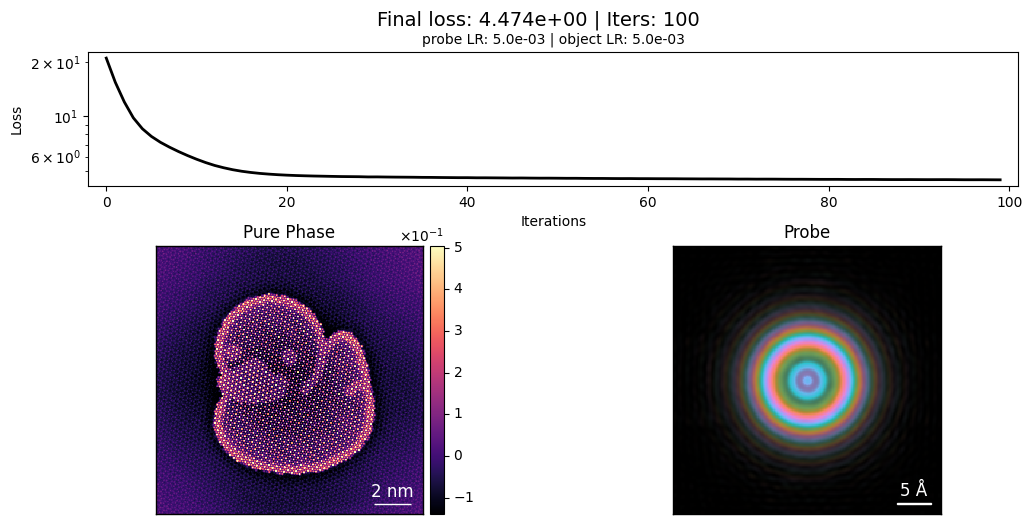

In [17]:
ptycho_best = PtychoLite.from_dataset(
    dset=pdset,
    num_slices=1,
    num_probes=1,
    obj_type="pure_phase",
    energy=PROBE_ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    defocus=best_defocus_lite,
    obj_padding_px=(32, 32),
    device="gpu",
    rng=42,
)

ptycho_best.reconstruct(
    num_iters=100,
    reset=True,
    lr_obj=5e-3,
    lr_probe=5e-3,
    batch_size=125,
    device="gpu",
).visualize()

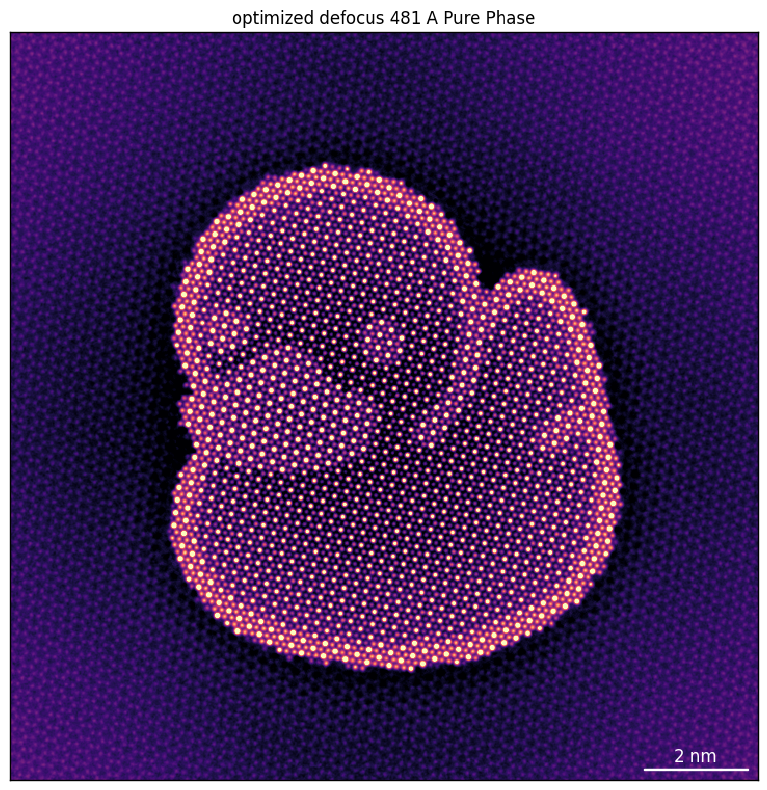

In [18]:
ptycho_best.show_obj(axsize=(8, 8), cmap="magma", title=f"optimized defocus {best_defocus_lite:.0f} A")

-- End notebook --